# DeepSeek-Coder-1.3B-Instruct

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [2]:
!pip install -q transformers datasets accelerate peft scikit-learn sentencepiece


In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
from torch import nn

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)

# ── Style toàn cục ────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 140,
    "font.size": 11,
    "font.family": "DejaVu Sans",
    "axes.facecolor": "#F8F9FA",
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE = ["#3A86FF", "#FF6B6B", "#06D6A0", "#FFD166"]

# ── Configuration ──────────────────────────────────────────────────────────
MODEL_ID   = "deepseek-ai/deepseek-coder-1.3b-instruct"
HF_TOKEN   = ""

MAX_LEN    = 512
TRAIN_SEED = 42
# [FIX 1] Dùng toàn bộ dataset
TRAIN_SIZE = 21854
VALID_SIZE = 2732
BATCH_SIZE = 2
GRAD_ACC   = 8
# [FIX 2] LR thấp hơn để tránh overfit
LR         = 2e-5
EPOCHS     = 10

# [FIX 3] LoRA capacity cao hơn
LORA_R     = 64
LORA_ALPHA = 128
LORA_DROP  = 0.05
NUM_LABELS = 2
OUTPUT_DIR = "./results-deepseek-coder-1.3b-instruct"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"Model  : {MODEL_ID}")


Device : cuda
Model  : deepseek-ai/deepseek-coder-1.3b-instruct


In [4]:
# Log in to HuggingFace (required for gated models)
from huggingface_hub import login
if HF_TOKEN:
    login(token=HF_TOKEN)
else:
    print("WARNING: HF_TOKEN not set. Gated models will fail to load.")


In [5]:
# Load and subsample dataset
dataset = load_dataset("google/code_x_glue_cc_defect_detection")

train_full = dataset["train"].shuffle(seed=TRAIN_SEED)
valid_full = dataset["validation"].shuffle(seed=TRAIN_SEED)
test_split = dataset["test"]

train_sub = train_full.select(range(min(TRAIN_SIZE, len(train_full))))
valid_sub = valid_full.select(range(min(VALID_SIZE, len(valid_full))))

print(f"Train subset : {len(train_sub):,}")
print(f"Valid subset : {len(valid_sub):,}")
print(f"Test split   : {len(test_split):,}")

# Label check
import collections
print("Train label dist:", collections.Counter(train_sub["target"]))


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/2.21M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/2.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/21854 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2732 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2732 [00:00<?, ? examples/s]

Train subset : 21,854
Valid subset : 2,732
Test split   : 2,732
Train label dist: Counter({False: 11836, True: 10018})


In [6]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    token=HF_TOKEN if HF_TOKEN else None,
    trust_remote_code=True,
)

# Decoder-only models often lack a pad token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print("Vocab size :", tokenizer.vocab_size)
print("Pad token  :", tokenizer.pad_token)


config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size : 32000
Pad token  : <｜end▁of▁sentence｜>


In [7]:
# Tokenize datasets
def tokenize(batch):
    return tokenizer(
        batch["func"],
        truncation=True,
        max_length=MAX_LEN,
        padding=False,
    )

cols_to_remove = ["func", "project", "commit_id"]

train_tok = train_sub.map(tokenize, batched=True, remove_columns=cols_to_remove, load_from_cache_file=False)
valid_tok = valid_sub.map(tokenize, batched=True, remove_columns=cols_to_remove, load_from_cache_file=False)
test_tok  = test_split.map(tokenize, batched=True, remove_columns=cols_to_remove, load_from_cache_file=False)

train_tok = train_tok.rename_column("target", "labels")
valid_tok = valid_tok.rename_column("target", "labels")
test_tok  = test_tok.rename_column("target", "labels")

# Explicitly cast and disable caching for this step to ensure type consistency
from datasets import Value
train_tok = train_tok.cast_column("labels", Value("int64"))
valid_tok = valid_tok.cast_column("labels", Value("int64"))
test_tok  = test_tok.cast_column("labels", Value("int64"))

train_tok.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
valid_tok.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_tok.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("Tokenization and type casting complete.")
print("Train features:", train_tok.features)

Map:   0%|          | 0/21854 [00:00<?, ? examples/s]

Map:   0%|          | 0/2732 [00:00<?, ? examples/s]

Map:   0%|          | 0/2732 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/21854 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2732 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2732 [00:00<?, ? examples/s]

Tokenization and type casting complete.
Train features: {'id': Value('int32'), 'labels': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


In [8]:
# Load base model with classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=NUM_LABELS,
    token=HF_TOKEN if HF_TOKEN else None,
    trust_remote_code=True,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map="auto" if DEVICE == "cuda" else None,
    ignore_mismatched_sizes=True,
)

# Align pad token id
model.config.pad_token_id = tokenizer.pad_token_id

# Apply LoRA (PEFT)
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROP,
    bias="none",
    target_modules=["q_proj", "v_proj"],
)

model = get_peft_model(model, lora_config)

# Fix: Explicitly upcast trainable parameters to float32 to avoid GradScaler errors
for name, param in model.named_parameters():
    if param.requires_grad:
        param.data = param.data.to(torch.float32)

model.print_trainable_parameters()
model.config.pad_token_id = tokenizer.pad_token_id
model.config.problem_type = "single_label_classification"

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.69G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: deepseek-ai/deepseek-coder-1.3b-instruct
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 12,587,008 || all params: 1,293,002,752 || trainable%: 0.9735


In [9]:
# [FIX 4] Class weights để cải thiện Recall Defective
import collections

label_counts = collections.Counter(train_sub["target"])
n_clean  = label_counts[0]
n_defect = label_counts[1]
total    = n_clean + n_defect
print(f"Clean: {n_clean}, Defective: {n_defect}")

class_weights = torch.tensor([
    total / (2 * n_clean),
    total / (2 * n_defect)
], dtype=torch.float32).to(DEVICE)
print(f"Class weights: Clean={class_weights[0]:.3f}, Defective={class_weights[1]:.3f}")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0, average='macro'),
        "recall":    recall_score(labels, preds, zero_division=0, average='macro'),
        "f1":        f1_score(labels, preds, zero_division=0, average='macro'),
    }

# [FIX 4] Custom Trainer với weighted loss
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss = nn.CrossEntropyLoss(weight=class_weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

print("WeightedTrainer ready.")


Clean: 11836, Defective: 10018
Class weights: Clean=0.923, Defective=1.091
WeightedTrainer ready.


In [10]:
import torch
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACC,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=True,
    logging_steps=50,
    report_to="none",
    dataloader_num_workers=2,
    seed=TRAIN_SEED,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# [FIX 4] Dùng WeightedTrainer thay vì Trainer thường
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=valid_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("WeightedTrainer initialized.")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


WeightedTrainer initialized.


In [11]:
train_result = trainer.train()
print("Training complete.")
print(f"Training loss     : {train_result.training_loss:.4f}")
print(f"Training runtime  : {train_result.metrics['train_runtime']:.1f}s")


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,5.291302,0.657598,0.560761,0.569085,0.569387,0.560727
2,5.103927,0.627572,0.620059,0.611260,0.608345,0.608873
3,4.821722,0.614478,0.634700,0.626286,0.621485,0.622145
4,4.477243,0.632276,0.613836,0.619150,0.620608,0.613496
5,3.444254,0.664159,0.620791,0.620743,0.622852,0.619137
6,3.053042,0.761392,0.609810,0.616912,0.617926,0.609668


Training complete.
Training loss     : 4.3515
Training runtime  : 23848.5s


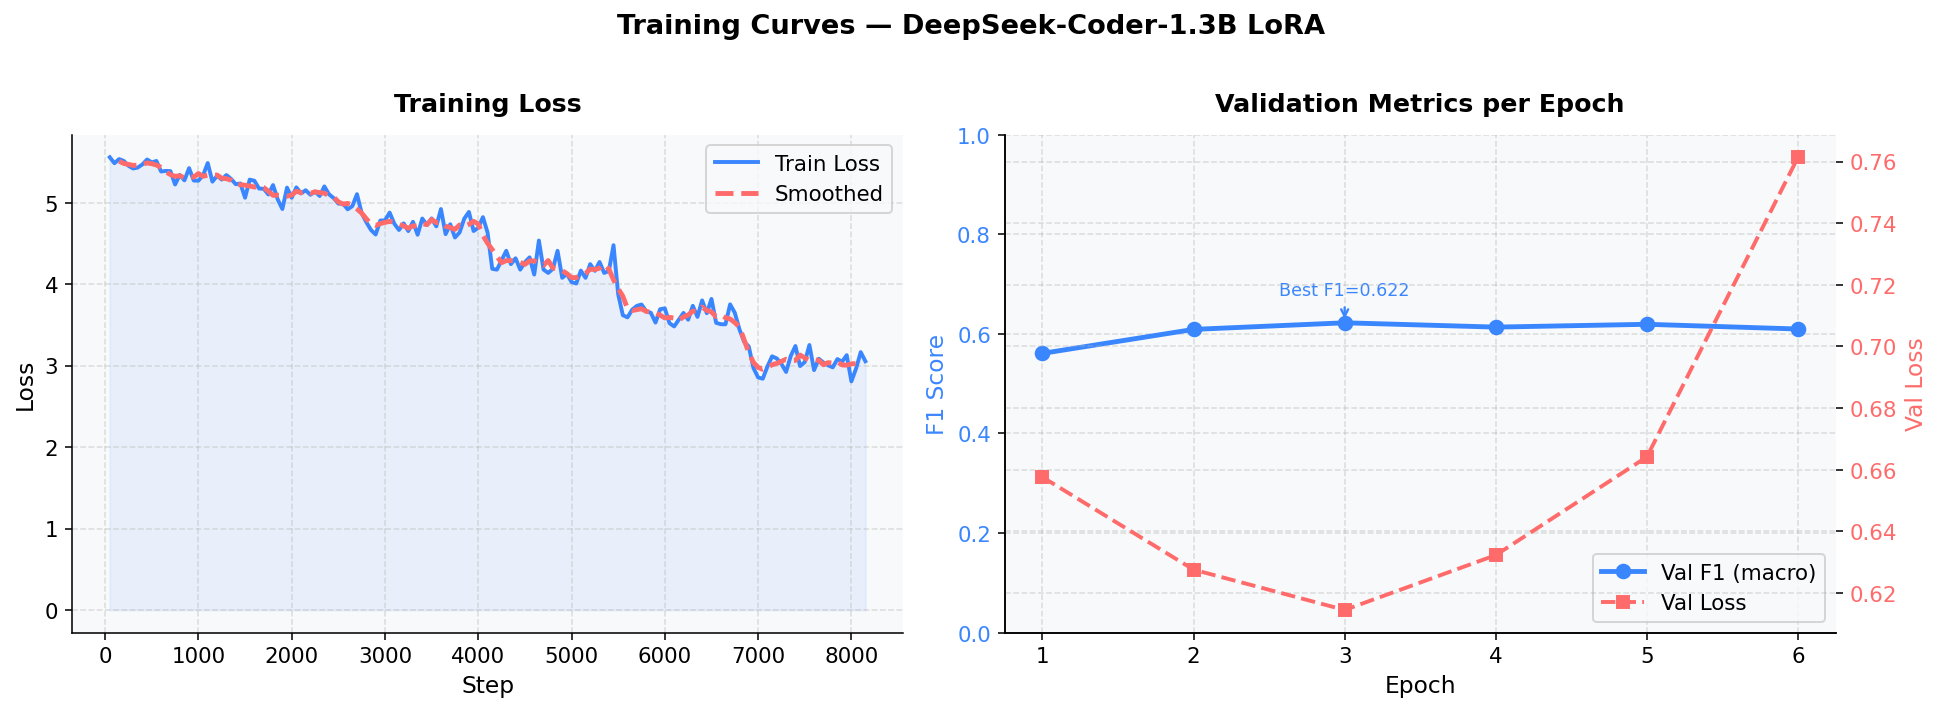

In [12]:
log_history = trainer.state.log_history
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in log_history if "eval_loss" in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

if train_logs:
    steps  = [x["step"] for x in train_logs]
    losses = [x["loss"] for x in train_logs]
    axes[0].plot(steps, losses, color=PALETTE[0], linewidth=2, label="Train Loss")
    if len(losses) > 5:
        smooth = pd.Series(losses).rolling(5, center=True).mean()
        axes[0].plot(steps, smooth, color='#FF6B6B', linewidth=2.5, linestyle='--', label='Smoothed')
    axes[0].set_xlabel("Step", fontsize=12)
    axes[0].set_ylabel("Loss", fontsize=12)
    axes[0].set_title("Training Loss", fontsize=13, fontweight="bold", pad=12)
    axes[0].legend(frameon=True, framealpha=0.8)
    axes[0].fill_between(steps, losses, alpha=0.08, color=PALETTE[0])

if eval_logs:
    epochs_e  = [x["epoch"] for x in eval_logs]
    f1_scores = [x.get("eval_f1", 0) for x in eval_logs]
    eval_loss = [x.get("eval_loss", 0) for x in eval_logs]
    color_f1   = PALETTE[0]
    color_loss = PALETTE[1]
    ax2 = axes[1].twinx()
    line1, = axes[1].plot(epochs_e, f1_scores, marker="o", color=color_f1,
                          linewidth=2.5, markersize=7, label="Val F1 (macro)")
    line2, = ax2.plot(epochs_e, eval_loss, marker="s", color=color_loss,
                      linewidth=2, linestyle='--', markersize=6, label="Val Loss")
    axes[1].set_xlabel("Epoch", fontsize=12)
    axes[1].set_ylabel("F1 Score", fontsize=12, color=color_f1)
    ax2.set_ylabel("Val Loss", fontsize=12, color=color_loss)
    axes[1].set_title("Validation Metrics per Epoch", fontsize=13, fontweight="bold", pad=12)
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis='y', labelcolor=color_f1)
    ax2.tick_params(axis='y', labelcolor=color_loss)
    best_idx = int(np.argmax(f1_scores))
    axes[1].annotate(f'Best F1={f1_scores[best_idx]:.3f}',
                     xy=(epochs_e[best_idx], f1_scores[best_idx]),
                     xytext=(0, 14), textcoords='offset points',
                     ha='center', fontsize=9, color=color_f1,
                     arrowprops=dict(arrowstyle='->', color=color_f1, lw=1.2))
    lines = [line1, line2]
    axes[1].legend(lines, [l.get_label() for l in lines], loc='lower right', frameon=True)

plt.suptitle("Training Curves — DeepSeek-Coder-1.3B LoRA", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("training_curves.png", bbox_inches="tight", dpi=150)
plt.show()


In [13]:
# Evaluate on test set
test_output = trainer.predict(test_tok)
logits = test_output.predictions
labels = test_output.label_ids
probs  = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
preds  = np.argmax(logits, axis=-1)

acc = accuracy_score(labels, preds)
pre = precision_score(labels, preds, zero_division=0)
rec = recall_score(labels, preds, zero_division=0)
f1  = f1_score(labels, preds, zero_division=0)
fpr, tpr, _ = roc_curve(labels, probs)
roc_auc = auc(fpr, tpr)

print("=== Test Set Evaluation ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {pre:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC       : {roc_auc:.4f}")
print()
print(classification_report(labels, preds, target_names=["Clean", "Defective"]))


=== Test Set Evaluation ===
Accuracy  : 0.6373
Precision : 0.6252
Recall    : 0.5251
F1 Score  : 0.5708
AUC       : 0.6851

              precision    recall  f1-score   support

       Clean       0.64      0.73      0.69      1477
   Defective       0.63      0.53      0.57      1255

    accuracy                           0.64      2732
   macro avg       0.64      0.63      0.63      2732
weighted avg       0.64      0.64      0.63      2732



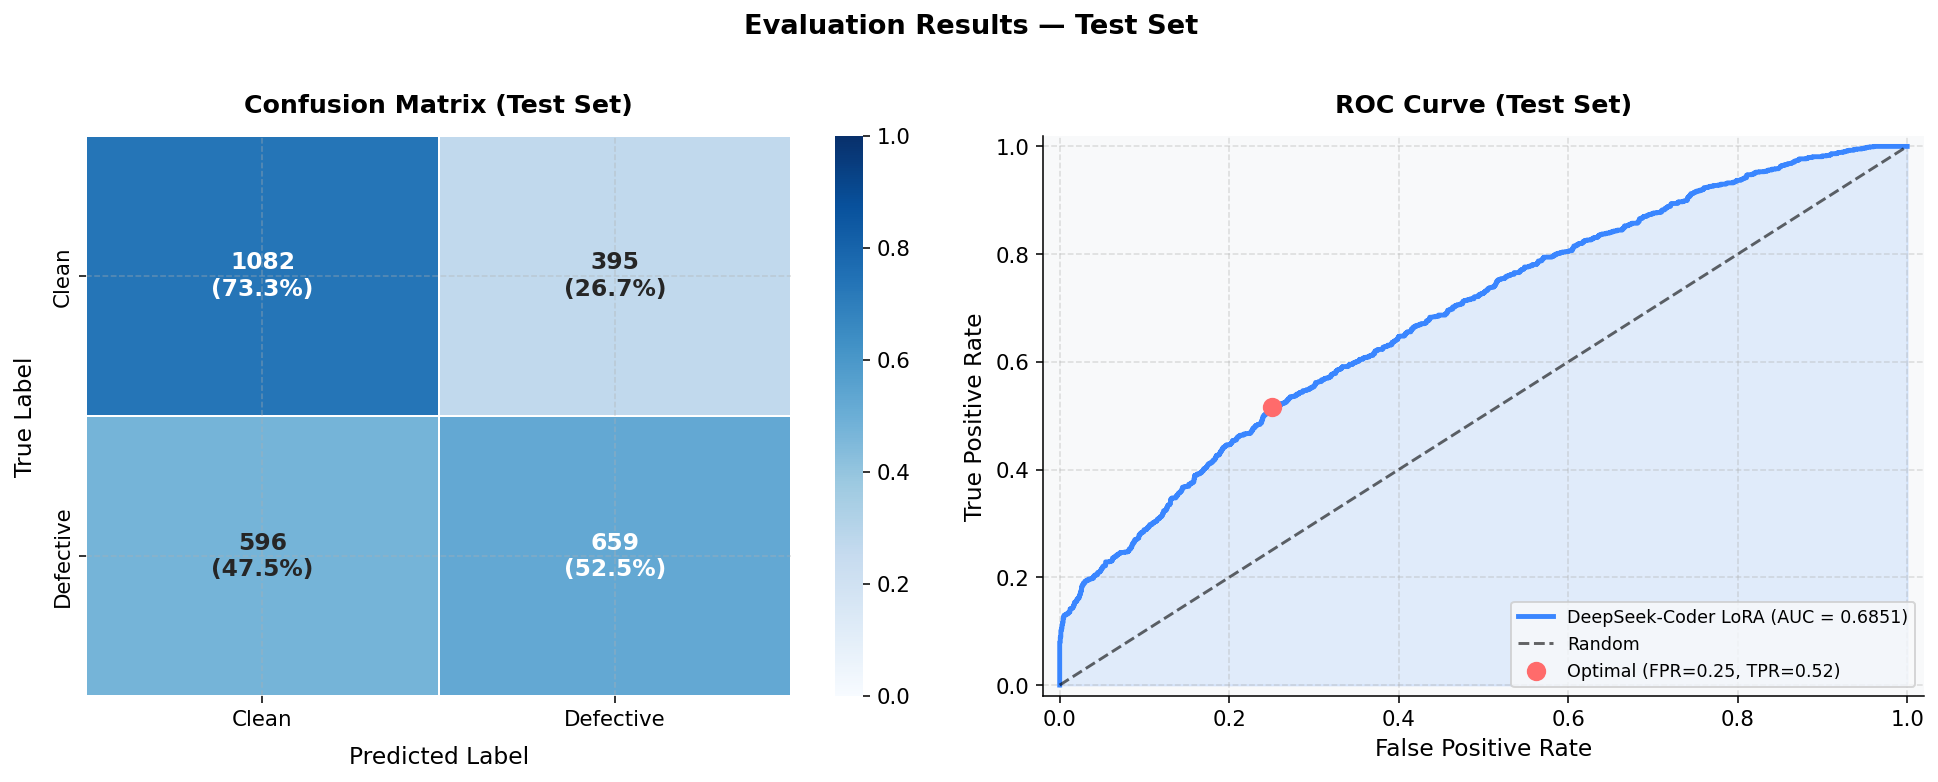

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('white')

from sklearn.metrics import confusion_matrix as cm_fn
cm = cm_fn(labels, preds, labels=[0, 1])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
annot = np.array([[f"{v}\n({p:.1%})" for v, p in zip(row_v, row_p)]
                  for row_v, row_p in zip(cm, cm_norm)])

sns.heatmap(cm_norm, annot=annot, fmt="", cmap="Blues",
            xticklabels=["Clean", "Defective"],
            yticklabels=["Clean", "Defective"],
            ax=axes[0], linewidths=1, linecolor='white',
            vmin=0, vmax=1,
            annot_kws={"size": 12, "weight": "bold"})
axes[0].set_xlabel("Predicted Label", fontsize=12, labelpad=8)
axes[0].set_ylabel("True Label", fontsize=12, labelpad=8)
axes[0].set_title("Confusion Matrix (Test Set)", fontsize=13, fontweight="bold", pad=12)

axes[1].plot(fpr, tpr, color=PALETTE[0], linewidth=2.5,
             label=f"DeepSeek-Coder LoRA (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Random", alpha=0.6)
axes[1].fill_between(fpr, tpr, alpha=0.12, color=PALETTE[0])
j_scores = tpr - fpr
opt_idx  = np.argmax(j_scores)
axes[1].scatter(fpr[opt_idx], tpr[opt_idx], color=PALETTE[1], s=80, zorder=5,
                label=f"Optimal (FPR={fpr[opt_idx]:.2f}, TPR={tpr[opt_idx]:.2f})")
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate", fontsize=12)
axes[1].set_title("ROC Curve (Test Set)", fontsize=13, fontweight="bold", pad=12)
axes[1].legend(loc="lower right", fontsize=9, frameon=True)
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.02)

plt.suptitle("Evaluation Results — Test Set", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("evaluation_results.png", bbox_inches="tight", dpi=150)
plt.show()


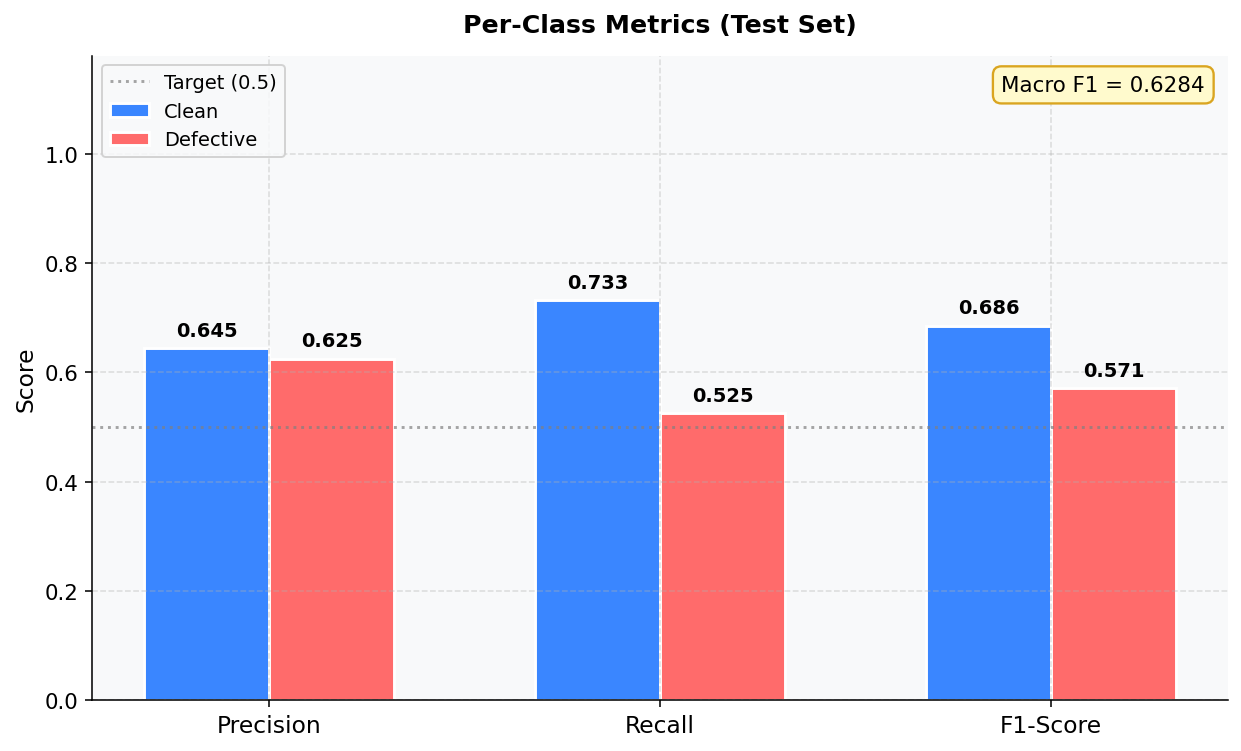

In [15]:
class_report = classification_report(
    labels, preds,
    target_names=["Clean", "Defective"],
    output_dict=True
)

metrics = ["precision", "recall", "f1-score"]
metric_labels = ["Precision", "Recall", "F1-Score"]
x = np.arange(len(metrics))
width = 0.32

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('white')

bars1 = ax.bar(x - width/2,
               [class_report["Clean"][m] for m in metrics],
               width, label="Clean", color=PALETTE[0], edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2,
               [class_report["Defective"][m] for m in metrics],
               width, label="Defective", color=PALETTE[1], edgecolor='white', linewidth=1.5)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.015,
            f"{h:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Target (0.5)', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=12)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Per-Class Metrics (Test Set)", fontsize=13, fontweight="bold", pad=12)
ax.legend(frameon=True, framealpha=0.85, fontsize=10)

macro_f1 = class_report['macro avg']['f1-score']
ax.text(0.98, 0.97, f"Macro F1 = {macro_f1:.4f}",
        transform=ax.transAxes, ha='right', va='top', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFFACD', edgecolor='#DAA520', linewidth=1.2))

plt.tight_layout()
plt.savefig("per_class_metrics.png", bbox_inches="tight", dpi=150)
plt.show()


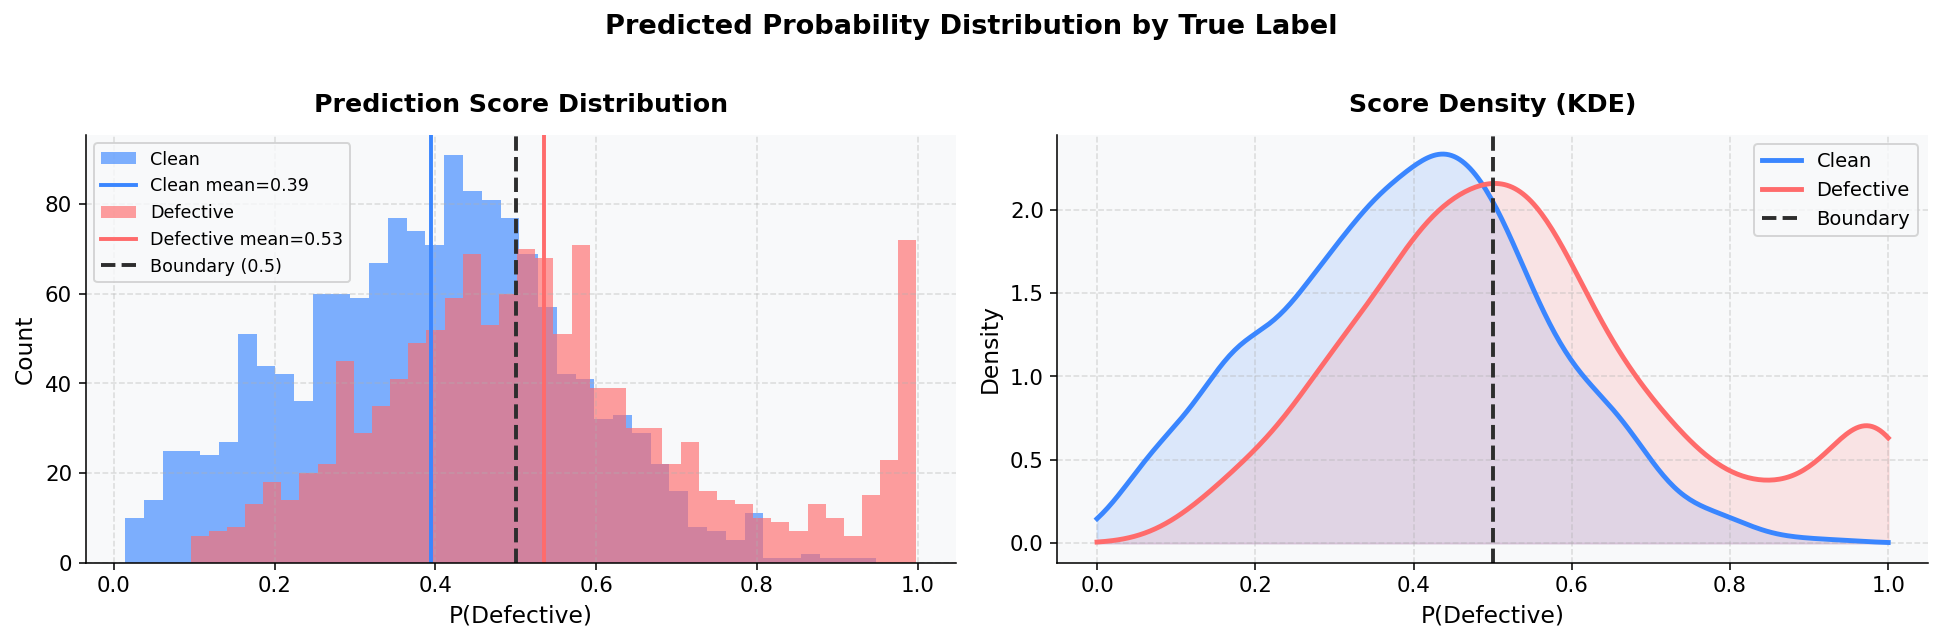

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.patch.set_facecolor('white')

for label_val, color, name in zip([0, 1], [PALETTE[0], PALETTE[1]], ["Clean", "Defective"]):
    subset = probs[labels == label_val]
    axes[0].hist(subset, bins=40, alpha=0.65, color=color, label=name, edgecolor='none')
    axes[0].axvline(subset.mean(), color=color, linestyle='-', linewidth=2,
                    label=f"{name} mean={subset.mean():.2f}")
axes[0].axvline(0.5, color='#2D2D2D', linestyle='--', linewidth=2, label="Boundary (0.5)")
axes[0].set_xlabel("P(Defective)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("Prediction Score Distribution", fontsize=13, fontweight="bold", pad=12)
axes[0].legend(fontsize=9, frameon=True)

from scipy.stats import gaussian_kde
x_range = np.linspace(0, 1, 300)
for label_val, color, name in zip([0, 1], [PALETTE[0], PALETTE[1]], ["Clean", "Defective"]):
    subset = probs[labels == label_val]
    if len(np.unique(subset)) > 1:
        kde = gaussian_kde(subset)
        axes[1].plot(x_range, kde(x_range), color=color, linewidth=2.5, label=name)
        axes[1].fill_between(x_range, kde(x_range), alpha=0.15, color=color)
axes[1].axvline(0.5, color='#2D2D2D', linestyle='--', linewidth=2, label="Boundary")
axes[1].set_xlabel("P(Defective)", fontsize=12)
axes[1].set_ylabel("Density", fontsize=12)
axes[1].set_title("Score Density (KDE)", fontsize=13, fontweight="bold", pad=12)
axes[1].legend(fontsize=10, frameon=True)

plt.suptitle("Predicted Probability Distribution by True Label", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("score_distribution.png", bbox_inches="tight", dpi=150)
plt.show()


In [17]:
# Final results summary
print("=== Final Results Summary ===")
results_df = pd.DataFrame([{
    "Model": MODEL_ID,
    "Accuracy":  round(acc, 4),
    "Precision": round(pre, 4),
    "Recall":    round(rec, 4),
    "F1":        round(f1, 4),
    "AUC":       round(roc_auc, 4),
}])
print(results_df.to_string(index=False))


=== Final Results Summary ===
                                   Model  Accuracy  Precision  Recall     F1    AUC
deepseek-ai/deepseek-coder-1.3b-instruct    0.6373     0.6252  0.5251 0.5708 0.6851


In [18]:
# Save the fine-tuned model
model.save_pretrained(OUTPUT_DIR + "/best_model")
tokenizer.save_pretrained(OUTPUT_DIR + "/best_model")
print(f"Model saved to: {OUTPUT_DIR}/best_model")


Model saved to: ./results-deepseek-coder-1.3b-instruct/best_model
